# Topological Transitions

## Sliding Windows

Financial markets are dynamic so we focus on a fixed number of recent periods to analyze time series. We apply sliding windows that consist of a fixed size of consecutive points in time and move forward one step in time. Each window of size (w,4) is our point cloud in 4D.

### Sliding Window Size

We are taking w = 50 and w = 100 following Gidea & Katz.

In [7]:
import pandas as pd
import numpy as np
import yfinance as yf
import math as mt

In [8]:
# Download historical data for the S&P 500, NASDAQ, Dow Jones Industrial Average, and Russell 2000 indices from 1999 to 2021
SP500 = yf.download("^GSPC", start="1999-01-01", end="2021-12-31")
NASDAQ = yf.download("^IXIC", start="1999-01-01", end="2021-12-31")
DJIA = yf.download("^DJI", start="1999-01-01", end="2021-12-31")
RUSSELL2000 = yf.download("^RUT", start="1999-01-01", end="2021-12-31")

# Assets returns
SP500_returns = np.log(SP500["Close"]/SP500["Close"].shift(1))
NASDAQ_returns = np.log(NASDAQ["Close"]/NASDAQ["Close"].shift(1))
DJIA_returns = np.log(DJIA["Close"]/DJIA["Close"].shift(1))
RUSSELL2000_returns = np.log(RUSSELL2000["Close"]/RUSSELL2000["Close"].shift(1))

# Combine the returns into a single DataFrame and clean
market_returns = pd.concat([SP500_returns, NASDAQ_returns, DJIA_returns, RUSSELL2000_returns], axis=1)
market_returns.dropna(inplace=True)
market_returns.rename(columns={"^GSPC": "SP500", "^IXIC": "NASDAQ", "^DJI": "DJIA", "^RUT": "Russell2000"}, inplace=True)



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [9]:
# Slicing window size
w = 50

# Slicing windows function
def slicing_windows(DataFrame, t, w):
    if t < 0 or t > len(DataFrame) - w:
        raise ValueError("Invalid starting index for slicing windows.")
    else:    
        point_cloud = DataFrame.iloc[t:t+w].values
    return point_cloud

In [10]:
all_windows = []
for t in range(len(market_returns) - w + 1):
    window = slicing_windows(market_returns, t, w)
    all_windows.append(window)

## Persistence Diagrams

*Persistence diagrams* calculate the amount and duration of loops (H1) and connected components (H0) in our space.

In [11]:
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt

In [12]:
results = ripser(all_windows[0])
diagrams = results['dgms']

H0: (50, 2)
H1: (9, 2)


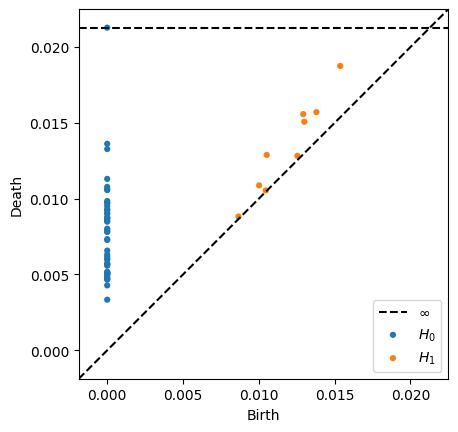

In [13]:
print("H0:", diagrams[0].shape) # H0 
print("H1:", diagrams[1].shape) # H1
plot_diagrams(diagrams, show=True)


## Observations

The persistence diagrams tell us that it has a diameter of approximately 0.021, and that 9 loops formed, but we have 4 of them really close to the line that represent noise and don't have significant topological features.

In [15]:
%%time

persistence_diagrams = []

for i in range(len(all_windows)):
    results = ripser(all_windows[i])
    diagrams = results['dgms']
    persistence_diagrams.append(diagrams)
    

CPU times: user 22.4 s, sys: 4.72 ms, total: 22.4 s
Wall time: 22.5 s


In [17]:

print(len(persistence_diagrams))
print(persistence_diagrams[0][1].shape)  # H1 of first window

5737
(9, 2)


We have calculated 5737 persistence diagrams for each of our windows. We verified that `persistence_diagrams[0][1]` coincides with what we had already calculated.

In `persistence_diagrams[i][1]` we have the amount of loops (H1) that were born and died in the window "i". We'll use this to calculate persistence landscapes and $L^2$ norms.